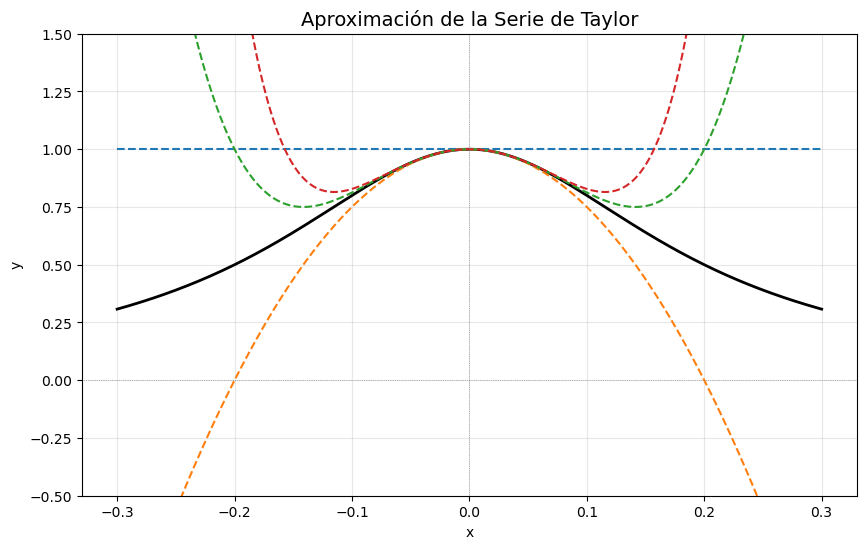

In [17]:
import numpy as np
import sympy as sp
# Definir serie de tylor de la funcion 
#definir primero la funcion inicial:
def f(x):
    return 1/(25*x**2 +1) 
def funtylor0(x):
    return np.ones_like(x) #dado que retornar 1 es diferente en el lenguaje, se lo define de esta manera para que devuelva un arreglo
def funtylor2(x):
    return 1-25*x**2
def funtylor4(x):
    return 1-25*x**2+625*x**4
def funtylor6(x):
    return 1-25*x**2+625*x**4+15625*x**6



#Graficar la serie
import matplotlib.pyplot as plt
x = np.linspace(-0.3, 0.3, 500)
plt.figure(figsize=(10, 6))

plt.plot(x, f(x), label='Función Original $f(x)$', color='black', linewidth=2)
plt.plot(x, funtylor0(x), label='Taylor Orden 0', linestyle='--')
plt.plot(x, funtylor2(x), label='Taylor Orden 2', linestyle='--')
plt.plot(x, funtylor4(x), label='Taylor Orden 4', linestyle='--')
plt.plot(x, funtylor6(x), label='Taylor Orden 6', linestyle='--')

plt.title('Aproximación de la Serie de Taylor', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='gray', linewidth=0.5, linestyle=':')
plt.axvline(0, color='gray', linewidth=0.5, linestyle=':')
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.show()

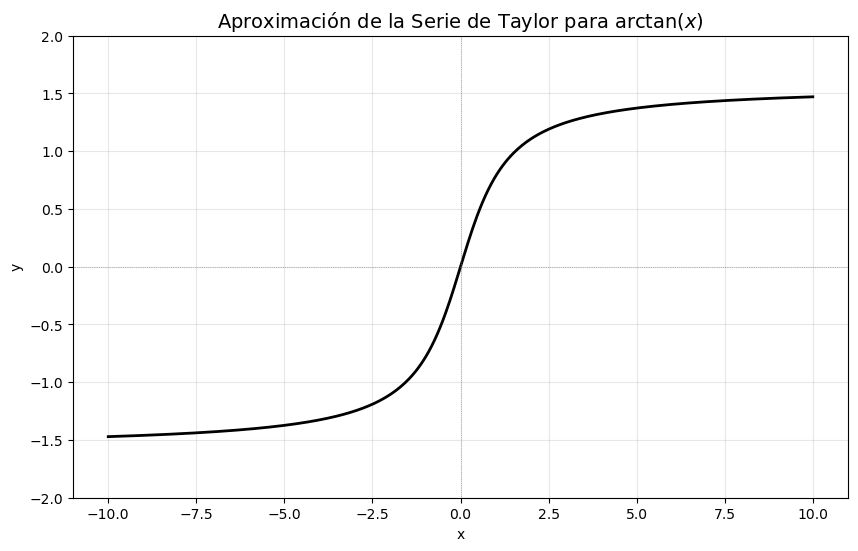

In [ ]:
def f2(x):
    return np.arctan(x)

x = np.linspace(-10, 10, 500)

# 4. Graficamos
plt.figure(figsize=(10, 6))

plt.plot(x, f2(x), label='Función Original $\\arctan(x)$', color='black', linewidth=2)
plt.title('Aproximación de la Serie de Taylor para $\\arctan(x)$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='gray', linewidth=0.5, linestyle=':')
plt.axvline(0, color='gray', linewidth=0.5, linestyle=':')
plt.ylim(-2, 2) # Limitamos Y para observar la divergencia fuera de [-1, 1]
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
# 1. Asegúrate de definir 'x' como un símbolo puro de SymPy
x = sp.Symbol('x') 

def taylor(f_expr, var, x0, n):
    serie = 0
    for k in range(n + 1):
           d = sp.diff(f_expr, var, k)
           serie += d.subs(var, x0) / sp.factorial(k) * (var - x0)**k
    return sp.expand(serie)


taylor_expr = taylor(sp.atan(x), x, 1, 3)

print(taylor_expr)

x**3/12 - x**2/2 + 5*x/4 - 5/6 + pi/4


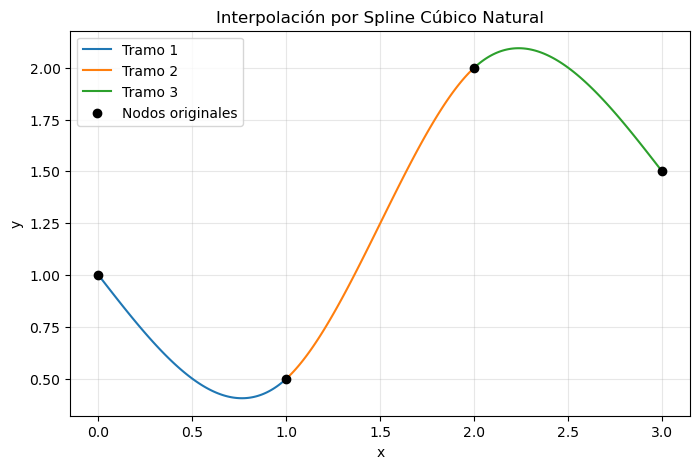

In [20]:
## Spline Cúbico natural
import numpy as np

def spline_cubico_natural(x_datos, y_datos):
    """
    Construye un Spline Cúbico Natural a partir de puntos dados.
    Sigue exactamente el pseudocódigo clásico de Burden & Faires.
    """
    # ENTRADA: n, x_0, ..., x_n, y los valores a_0, ..., a_n
    x = np.array(x_datos, dtype=float)
    a = np.array(y_datos, dtype=float)
    n = len(x) - 1  # Ya que los índices van de 0 a n (n+1 puntos)
    
    # Inicialización de arreglos para los coeficientes y variables intermedias
    h = np.zeros(n)
    alpha = np.zeros(n)
    l = np.zeros(n + 1)
    mu = np.zeros(n + 1)
    z = np.zeros(n + 1)
    
    c = np.zeros(n + 1)
    b = np.zeros(n)
    d = np.zeros(n)
    
    # Paso 1: Calcular las distancias h_i
    for i in range(n):
        h[i] = x[i+1] - x[i]
        
    # Paso 2: Calcular los valores alpha_i
    for i in range(1, n):
        alpha[i] = (3/h[i]) * (a[i+1] - a[i]) - (3/h[i-1]) * (a[i] - a[i-1])
        
    # Paso 3: Condiciones iniciales para la solución del sistema tridiagonal
    l[0] = 1.0
    mu[0] = 0.0
    z[0] = 0.0
    
    # Paso 4: Sustitución hacia adelante para resolver el sistema tridiagonal
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
        
    # Paso 5: Condiciones finales para el Spline Natural (S''(x_0) = S''(x_n) = 0)
    l[n] = 1.0
    z[n] = 0.0
    c[n] = 0.0
    
    # Paso 6: Sustitución hacia atrás para obtener los coeficientes finales
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (a[j+1] - a[j])/h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
        
    # Paso 7: SALIDA (a, b, c, d para j = 0, ..., n-1)
    # Devolvemos solo los primeros n elementos de 'c' para que coincida en tamaño con b y d
    return a[:n], b, c[:n], d

## Uso y Grafica

import matplotlib.pyplot as plt

# Datos de prueba (puedes usar tus funciones anteriores para generar puntos)
x_puntos = [0.0, 1.0, 2.0, 3.0]
y_puntos = [1.0, 0.5, 2.0, 1.5]

# Obtener los coeficientes del spline
a, b, c, d = spline_cubico_natural(x_puntos, y_puntos)

# Graficar el Spline tramo por tramo
plt.figure(figsize=(8, 5))

for j in range(len(x_puntos) - 1):
    # Generar puntos intermedios dentro del tramo j para que se vea una curva suave
    x_tramo = np.linspace(x_puntos[j], x_puntos[j+1], 100)
    
    # Evaluar la fórmula del spline cúbico para este tramo
    dx = x_tramo - x_puntos[j]
    y_tramo = a[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    
    # Graficar el tramo actual
    plt.plot(x_tramo, y_tramo, label=f'Tramo {j+1}')

# Graficar los nodos originales para verificar la interpolación
plt.scatter(x_puntos, y_puntos, color='black', zorder=5, label='Nodos originales')

plt.title('Interpolación por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

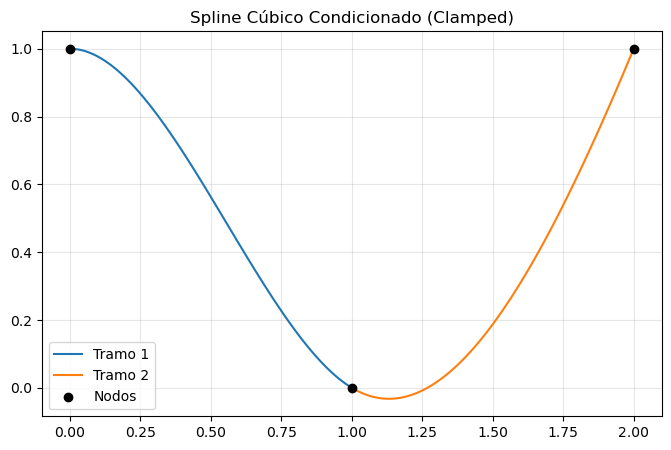

In [21]:
# Spline Cúbico Condicionado
import numpy as np

def spline_cubico_condicionado(x_datos, y_datos, fpo, fpn):
    """
    Construye un Spline Cúbico Condicionado (Clamped Spline) a partir de puntos dados.
    Requiere las pendientes extremas fpo (FPO) y fpn (FPN).
    Sigue el pseudocódigo clásico de Burden & Faires.
    """
    # ENTRADA: n, x_0, ..., x_n, a_0, ..., a_n, FPO, FPN
    x = np.array(x_datos, dtype=float)
    a = np.array(y_datos, dtype=float)
    n = len(x) - 1  # Ya que los índices van de 0 a n
    
    # Inicialización de arreglos para coeficientes y variables del sistema tridiagonal
    h = np.zeros(n)
    alpha = np.zeros(n + 1)  # Nota: aquí alpha necesita llegar hasta el índice n
    l = np.zeros(n + 1)
    mu = np.zeros(n + 1)
    z = np.zeros(n + 1)
    
    c = np.zeros(n + 1)
    b = np.zeros(n)
    d = np.zeros(n)
    
    # Paso 1: Calcular las distancias h_i
    for i in range(n):
        h[i] = x[i+1] - x[i]
        
    # Paso 2: Calcular alpha_0 y alpha_n usando las derivadas de frontera (FPO y FPN)
    alpha[0] = 3 * (a[1] - a[0]) / h[0] - 3 * fpo
    alpha[n] = 3 * fpn - 3 * (a[n] - a[n-1]) / h[n-1]
        
    # Paso 3: Calcular el resto de los alpha_i para los puntos internos
    for i in range(1, n):
        alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])
        
    # Paso 4: Condiciones iniciales para el sistema tridiagonal acondicionado
    l[0] = 2 * h[0]
    mu[0] = 0.5
    z[0] = alpha[0] / l[0]
    
    # Paso 5: Sustitución hacia adelante para los puntos internos
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
        
    # Paso 6: Condiciones finales modificadas para la frontera rígida
    l[n] = h[n-1] * (2.0 - mu[n-1])
    z[n] = (alpha[n] - h[n-1] * z[n-1]) / l[n]
    c[n] = z[n]
    
    # Paso 7: Sustitución hacia atrás para obtener los coeficientes finales
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
        
    # Paso 8: SALIDA (a, b, c, d para j = 0, ..., n-1)
    return a[:n], b, c[:n], d



## Uso y Grafica
import matplotlib.pyplot as plt

# Puntos por donde debe pasar el spline
x_nodos = [0.0, 1.0, 2.0]
y_nodos = [1.0, 0.0, 1.0]

# Forzamos las pendientes en los extremos:
FPO = 0.0  # Empieza totalmente plano
FPN = 2.0  # Termina subiendo con un ángulo marcado

# Calculamos coeficientes condicionados
a, b, c, d = spline_cubico_condicionado(x_nodos, y_nodos, FPO, FPN)

# Graficamos
plt.figure(figsize=(8, 5))
for j in range(len(x_nodos) - 1):
    x_tramo = np.linspace(x_nodos[j], x_nodos[j+1], 100)
    dx = x_tramo - x_nodos[j]
    y_tramo = a[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    plt.plot(x_tramo, y_tramo, label=f'Tramo {j+1}')

plt.scatter(x_nodos, y_nodos, color='black', zorder=5, label='Nodos')
plt.title('Spline Cúbico Condicionado (Clamped)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Eliminación Gaussinaa

In [22]:
import numpy as np

def eliminacion_gaussiana_general(A_matriz, b_vector):
    """
    Eliminación Gaussiana general para sistemas de cualquier dimensión (m x n).
    Soporta sistemas sobredeterminados y detecta si tienen solución o no.
    """
    A = np.array(A_matriz, dtype=float)
    b = np.array(b_vector, dtype=float).reshape(-1, 1)
    M = np.hstack((A, b))
    
    m, n_cols = A.shape  # m: ecuaciones (filas), n_cols: incógnitas (columnas)
    
    # --- PASO 1: PROCESO DE ELIMINACIÓN ---
    fila_actual = 0
    for col_actual in range(n_cols):
        if fila_actual >= m:
            break  # Nos quedamos sin filas antes de terminar las columnas
            
        # Buscar pivote en la columna actual, desde la fila_actual hacia abajo
        p = -1
        for row in range(fila_actual, m):
            if not np.isclose(M[row, col_actual], 0.0):
                p = row
                break
                
        # Si no hay pivote en esta columna, pasamos a la siguiente columna
        if p == -1:
            continue
            
        # Intercambiar filas si el pivote no está en la fila_actual
        if p != fila_actual:
            M[[fila_actual, p]] = M[[p, fila_actual]]
            
        # Eliminar los elementos debajo del pivote
        for j in range(fila_actual + 1, m):
            m_factor = M[j, col_actual] / M[fila_actual, col_actual]
            M[j] = M[j] - m_factor * M[fila_actual]
            
        fila_actual += 1

    # --- PASO 2: ANÁLISIS DE CONSISTENCIA (¿Tiene solución?) ---
    # Buscamos si existe alguna fila donde todos los coeficientes de A sean 0,
    # pero el término independiente en la columna aumentada (b) no lo sea.
    for i in range(m):
        coeficientes_cero = np.allclose(M[i, :n_cols], 0.0)
        resultado_no_cero = not np.isclose(M[i, n_cols], 0.0)
        if coeficientes_cero and resultado_no_cero:
            return "El sistema es inconsistente (no tiene solución exacta)"

    # --- PASO 3: SUSTITUCIÓN HACIA ATRÁS ---
    # Si pasó la prueba de consistencia, procedemos a resolver
    x = np.zeros(n_cols)
    
    # Buscamos las filas que realmente contienen ecuaciones útiles (descartando filas de ceros)
    filas_utiles = []
    for i in range(m):
        if not np.allclose(M[i, :n_cols], 0.0):
            filas_utiles.append(i)
            
    # Si tenemos menos ecuaciones útiles que incógnitas, hay infinitas soluciones
    if len(filas_utiles) < n_cols:
        return "El sistema tiene infinitas soluciones (grados de libertad)"
        
    # Resolver usando sustitución hacia atrás desde la última fila útil
    for idx in reversed(filas_utiles):
        # Encontrar la primera columna que tiene un elemento no nulo en esta fila (el pivote)
        pivote_col = np.where(~np.isclose(M[idx, :n_cols], 0.0))[0][0]
        
        suma = 0.0
        for j in range(pivote_col + 1, n_cols):
            suma += M[idx, j] * x[j]
            
        x[pivote_col] = (M[idx, n_cols] - suma) / M[idx, pivote_col]
        
    return x

In [23]:
# Definimos la matriz A y el vector b
A = [
    [1, 2],
    [1, -1],
    
]
b = [0, 0]

resultado = eliminacion_gaussiana_general(A, b)
print("Resultado:", resultado)

Resultado: [ 0. -0.]


In [24]:
A = [
    [2, 1],
    [1, 1],
    [1, -3]
]
b = [-1, 2, 5]

print("Resultado:", eliminacion_gaussiana_general(A, b))

Resultado: El sistema es inconsistente (no tiene solución exacta)


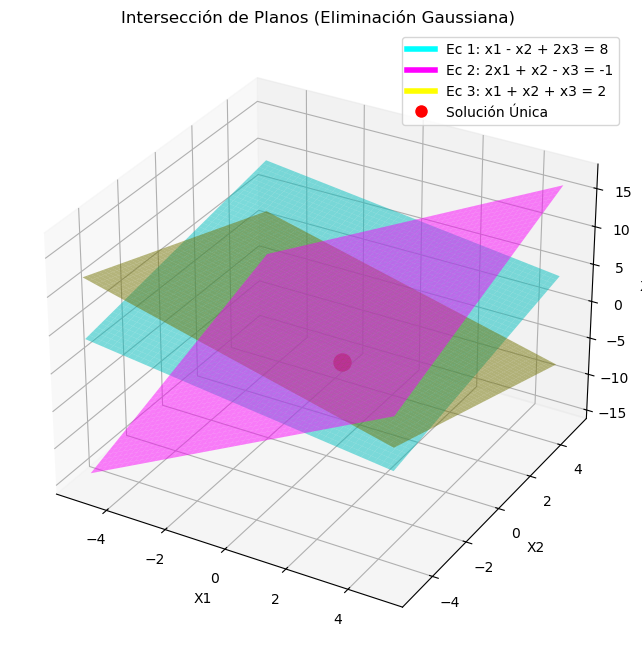

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Tu solución encontrada (la intersección)
solucion = np.array([1.57142857, -1.85714286, 2.28571429])

# 2. Crear una cuadrícula para los ejes X e Y
x_vals = np.linspace(-5, 5, 50)
y_vals = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x_vals, y_vals)

# 3. Despejar Z (x3) de cada una de tus tres ecuaciones:
# Ec 1:  1x - 1y + 2z = 8  ->  z = (8 - x + y) / 2
Z1 = (8 - X + Y) / 2

# Ec 2:  2x + 1y - 1z = -1 ->  z = 2x + y + 1
Z2 = 2*X + Y + 1

# Ec 3:  1x + 1y + 1z = 2  ->  z = 2 - x - y
Z3 = 2 - X - Y

# 4. Configurar la gráfica 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar cada plano con un color y transparencia (alpha) para ver a través de ellos
ax.plot_surface(X, Y, Z1, alpha=0.5, color='cyan', label='Ecuación 1')
ax.plot_surface(X, Y, Z2, alpha=0.5, color='magenta', label='Ecuación 2')
ax.plot_surface(X, Y, Z3, alpha=0.5, color='yellow', label='Ecuación 3')

# 5. Dibujar el punto de la solución (en rojo brillante)
ax.scatter(solucion[0], solucion[1], solucion[2], color='red', s=150, zorder=10, label='Solución')

# Etiquetas y detalles estéticos
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Intersección de Planos (Eliminación Gaussiana)')

# Un pequeño truco para arreglar las leyendas en superficies 3D de matplotlib
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='cyan', lw=4, label='Ec 1: x1 - x2 + 2x3 = 8'),
    Line2D([0], [0], color='magenta', lw=4, label='Ec 2: 2x1 + x2 - x3 = -1'),
    Line2D([0], [0], color='yellow', lw=4, label='Ec 3: x1 + x2 + x3 = 2'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Solución Única')
]
ax.legend(handles=legend_elements)

plt.show()

### Método de la bisección

In [1]:
import math

def biseccion(f, a, b, tolerancia=0.0001, max_iter=50):
    FA = f(a)
    FB = f(b)

    # Validar que el intervalo contenga una raíz
    if FA * FB > 0:
        print(f"Error: La función no cambia de signo en el intervalo [{a}, {b}].")
        return None

    print(f"\nIntervalo inicial: [{a}, {b}]")

    i = 1
    while i <= max_iter:
        p = a + (b - a) / 2
        FP = f(p)

        print(f"Iteración {i}: p = {p:.6f}, f(p) = {FP:.6f}, Intervalo = [{a:.6f}, {b:.6f}]")

        # Criterio de parada por tolerancia o raíz exacta
        if FP == 0 or (b - a) / 2 < tolerancia:
            print(f"\nRaíz aproximada encontrada: {p:.6f} en {i} iteraciones")
            return p

        i += 1
        
        # Actualización de extremos del intervalo
        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p

    print(f"\nEl método no alcanzó la tolerancia en {max_iter} iteraciones.")
    return p

# --- Ejemplo de uso con f(x) = sin(x) ---
# Definimos la función f(x)
def f(x):
    return math.sin(x)

# Ejecutamos el algoritmo en el intervalo [2, 4] para encontrar pi (~3.14159)
raiz = biseccion(f, a=2, b=4, tolerancia=0.0001, max_iter=20)


Intervalo inicial: [2, 4]
Iteración 1: p = 3.000000, f(p) = 0.141120, Intervalo = [2.000000, 4.000000]
Iteración 2: p = 3.500000, f(p) = -0.350783, Intervalo = [3.000000, 4.000000]
Iteración 3: p = 3.250000, f(p) = -0.108195, Intervalo = [3.000000, 3.500000]
Iteración 4: p = 3.125000, f(p) = 0.016592, Intervalo = [3.000000, 3.250000]
Iteración 5: p = 3.187500, f(p) = -0.045891, Intervalo = [3.125000, 3.250000]
Iteración 6: p = 3.156250, f(p) = -0.014657, Intervalo = [3.125000, 3.187500]
Iteración 7: p = 3.140625, f(p) = 0.000968, Intervalo = [3.125000, 3.156250]
Iteración 8: p = 3.148438, f(p) = -0.006845, Intervalo = [3.140625, 3.156250]
Iteración 9: p = 3.144531, f(p) = -0.002939, Intervalo = [3.140625, 3.148438]
Iteración 10: p = 3.142578, f(p) = -0.000985, Intervalo = [3.140625, 3.144531]
Iteración 11: p = 3.141602, f(p) = -0.000009, Intervalo = [3.140625, 3.142578]
Iteración 12: p = 3.141113, f(p) = 0.000479, Intervalo = [3.140625, 3.141602]
Iteración 13: p = 3.141357, f(p) = 0.0

###  Método de Newton

In [2]:
from scipy.optimize import newton

# 1. Definimos la función principal
def f(x):
    return math.sin(x)

# 2. Definimos la derivada de la función
def f_derivada(x):
    return math.cos(x)

# 3. Punto inicial (x0)
x0 = 3.0

# 4. Llamada al método de Newton especificando 'fprime'
raiz = newton(func=f, x0=x0, fprime=f_derivada, tol=0.0001)

print(f"Punto inicial x0: {x0}")
print(f"Raíz obtenida por Newton: {raiz:.6f}")

Punto inicial x0: 3.0
Raíz obtenida por Newton: 3.141593


### Formula del método de la Secante

x_n+1 = 
        x_n - (f(x_n)(x_n - x_n-1))

              ---------------------       

               (f(x_n) - f(x_n-1))

Actualizado